In [1]:
import pandas as pd
import numpy as np

In [2]:
date_rng = pd.date_range(start='1/1/2023', end='6/30/2023', freq='h')
df = pd.DataFrame(date_rng, columns=['timestamp'])

In [3]:
df['fridge'] = np.random.randint(50, 200, len(df)) * np.random.choice([0,1], len(df), p=[0.3,0.7])

In [4]:
month = df['timestamp'].dt.month
ac_prob = np.where(month >= 4, 0.8, 0.1)
df['ac'] = np.random.randint(1000, 2500, len(df)) * np.random.binomial(1, ac_prob)

In [5]:
hour = df['timestamp'].dt.hour
light_prob = np.where((hour >= 18) | (hour <= 6), 0.9, 0.1)

df['lights'] = np.random.randint(20, 100, len(df)) * np.random.binomial(1, light_prob)
df['microwave'] = np.random.randint(800, 1200, len(df)) * np.random.choice([0,1], len(df), p=[0.9,0.1])

In [6]:
df['total_power'] = df[['fridge','ac','lights','microwave']].sum(axis=1)
df.head()

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,0,1955,24,0,1979
1,2023-01-01 01:00:00,186,0,81,0,267
2,2023-01-01 02:00:00,111,1300,67,0,1478
3,2023-01-01 03:00:00,0,0,93,0,93
4,2023-01-01 04:00:00,0,0,26,0,26


In [ ]:
#analysis.ipynb

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
#data understanding

In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4321 entries, 0 to 4320
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    4321 non-null   datetime64[us]
 1   fridge       4321 non-null   int64         
 2   ac           4321 non-null   int32         
 3   lights       4321 non-null   int32         
 4   microwave    4321 non-null   int64         
 5   total_power  4321 non-null   int64         
dtypes: datetime64[us](1), int32(2), int64(3)
memory usage: 168.9 KB


,timestamp,fridge,ac,lights,microwave,total_power
count,4321,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000
mean,2023-04-01 00:00:00,86.838926,799.728766,32.152048,103.997223,1022.716964
min,2023-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-02-15 00:00:00,0.000000,0.000000,0.000000,0.000000,127.000000
50%,2023-04-01 00:00:00,93.000000,0.000000,25.000000,0.000000,1011.000000
75%,2023-05-16 00:00:00,148.000000,1690.000000,63.000000,0.000000,1875.000000
max,2023-06-30 00:00:00,199.000000,2498.000000,99.000000,1199.000000,3762.000000
std,NaN,68.944586,918.399676,34.289215,306.958475,970.507402


In [ ]:
## Trend Analysis

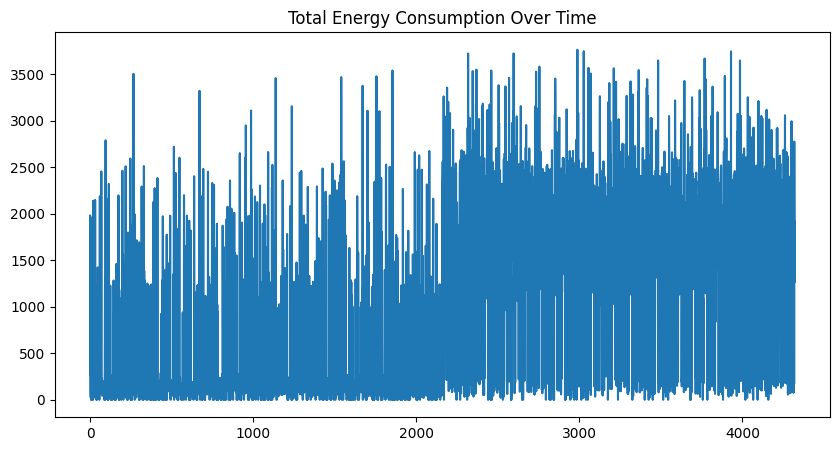

In [9]:
import matplotlib.pyplot as plt

df['total_power'].plot(figsize=(10,5))
plt.title("Total Energy Consumption Over Time")
plt.show()

In [ ]:
## Device Comparison

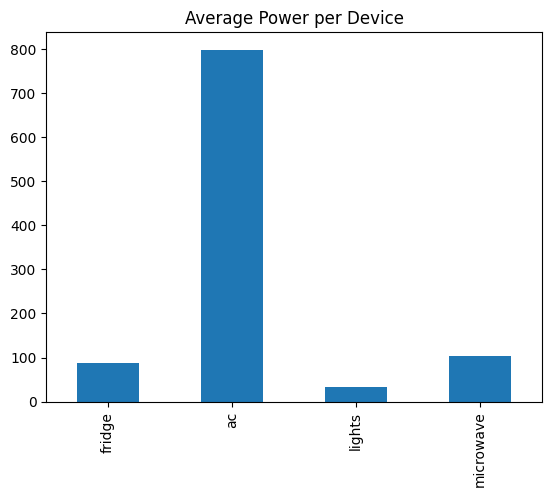

In [10]:
df[['fridge','ac','lights','microwave']].mean().plot(kind='bar')
plt.title("Average Power per Device")
plt.show()

In [ ]:
## Time Analysis

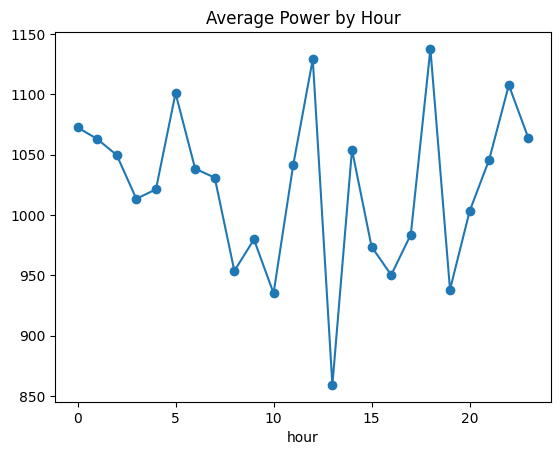

In [11]:
df['hour'] = df['timestamp'].dt.hour

df.groupby('hour')['total_power'].mean().plot(marker='o')
plt.title("Average Power by Hour")
plt.show()

In [ ]:
## Relationship Analysis

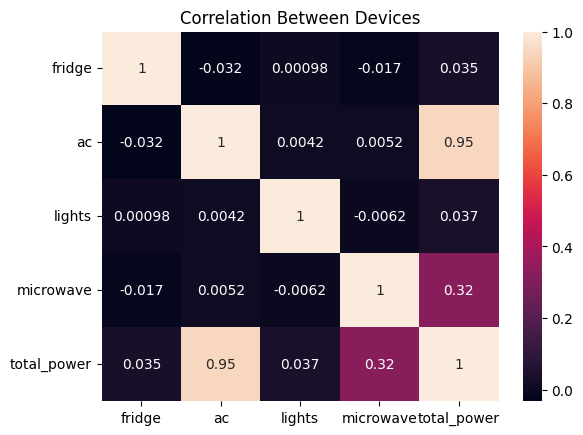

In [12]:
import seaborn as sns

sns.heatmap(df[['fridge','ac','lights','microwave','total_power']].corr(), annot=True)
plt.title("Correlation Between Devices")
plt.show()

In [ ]:
## Time Series Decomposition

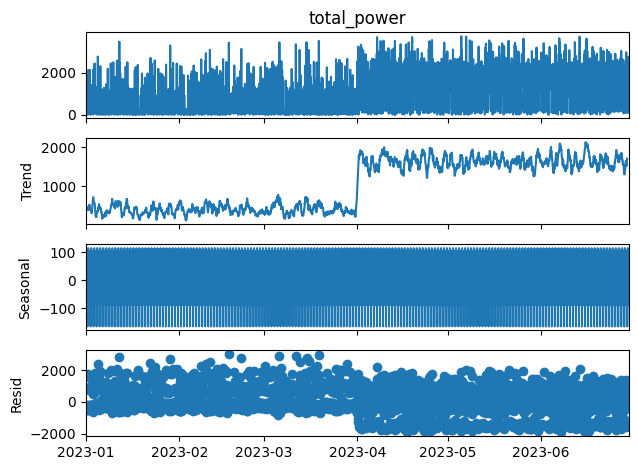

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set timestamp as index
df.set_index('timestamp', inplace=True)

# Decomposition (daily pattern → 24 hours)
decomposition = seasonal_decompose(df['total_power'], model='additive', period=24)

# Plot
decomposition.plot()
plt.show()

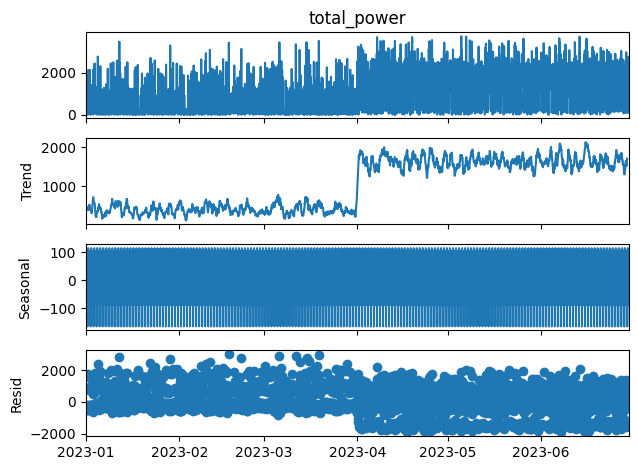

In [14]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposition using index
result = seasonal_decompose(df['total_power'], model='additive', period=24)

result.plot()
plt.show()

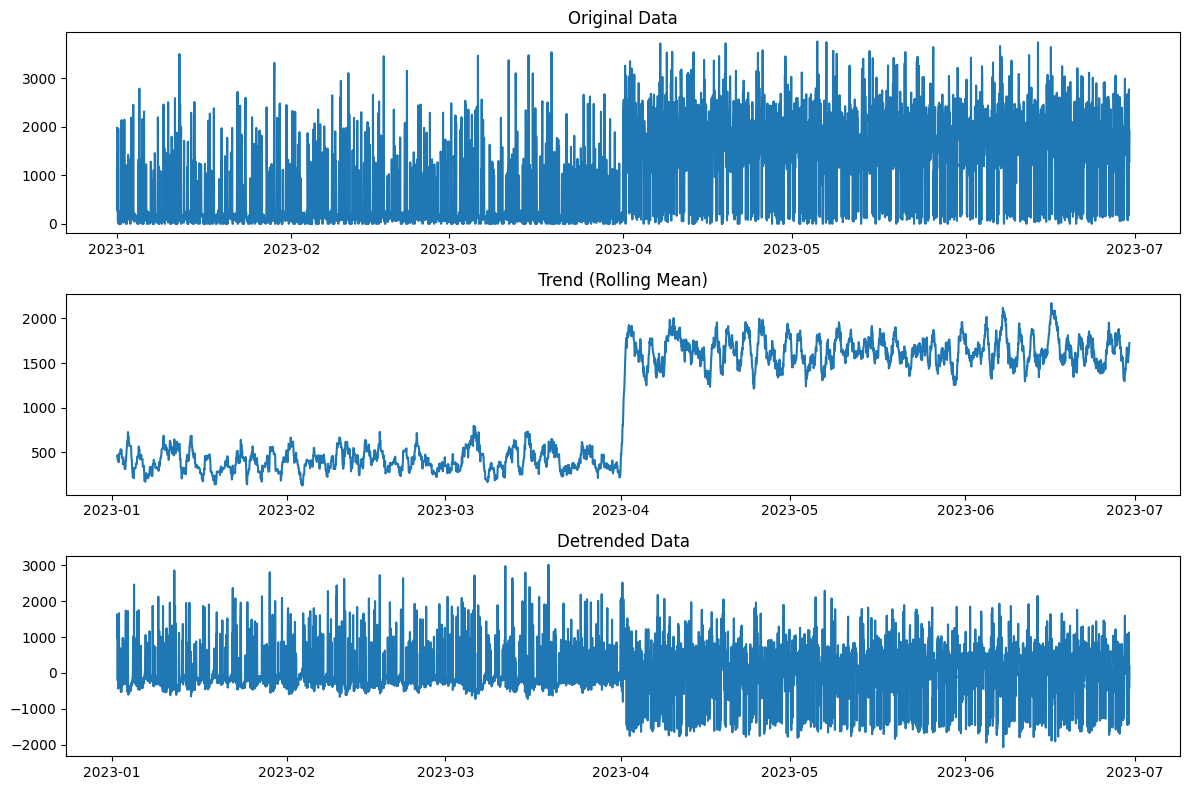

In [15]:
import matplotlib.pyplot as plt

# Make sure timestamp is index
df = df.copy()
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)

# 1. Trend (using rolling mean)
df['trend'] = df['total_power'].rolling(window=24).mean()

# 2. Detrended (remove trend)
df['detrended'] = df['total_power'] - df['trend']

# 3. Plot everything
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(df['total_power'])
plt.title("Original Data")

plt.subplot(3,1,2)
plt.plot(df['trend'])
plt.title("Trend (Rolling Mean)")

plt.subplot(3,1,3)
plt.plot(df['detrended'])
plt.title("Detrended Data")

plt.tight_layout()
plt.show()

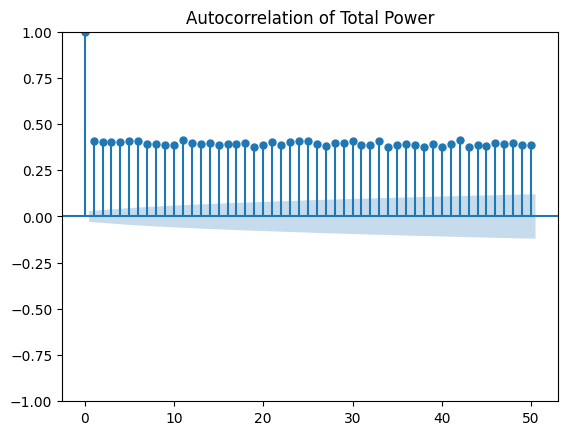

In [16]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['total_power'], lags=50)
plt.title("Autocorrelation of Total Power")
plt.show()

In [ ]:
## Partial Autocorrelation (PACF)

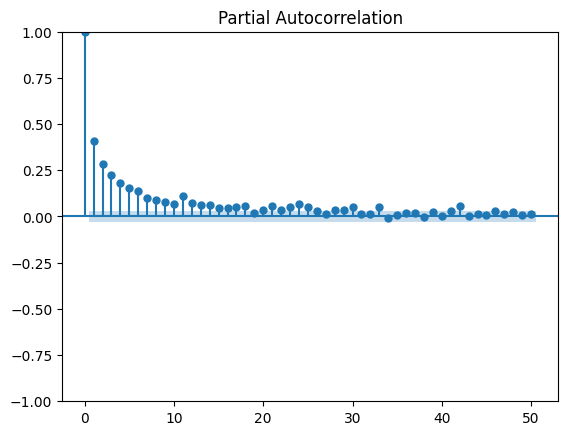

In [17]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['total_power'], lags=50)
plt.title("Partial Autocorrelation")
plt.show()

In [ ]:
#hourly.ipynb

In [18]:
df['hour'] = df.index.hour
df.head()

,fridge,ac,lights,microwave,total_power,hour,trend,detrended
timestamp,,,,,,,,
2023-01-01 00:00:00,0,1955,24,0,1979,0,NaN,NaN
2023-01-01 01:00:00,186,0,81,0,267,1,NaN,NaN
2023-01-01 02:00:00,111,1300,67,0,1478,2,NaN,NaN
2023-01-01 03:00:00,0,0,93,0,93,3,NaN,NaN
2023-01-01 04:00:00,0,0,26,0,26,4,NaN,NaN


In [ ]:
##hourly table

In [19]:
hourly_table = df.groupby('hour').agg({
    'total_power': ['mean','max','min'],
    'fridge': 'mean',
    'ac': 'mean',
    'lights': 'mean',
    'microwave': 'mean'
})

hourly_table

total_power               fridge          ac     lights   microwave
             mean   max min       mean        mean       mean        mean
hour                                                                     
0     1072.563536  3668   0  87.635359  820.712707  52.071823  112.143646
1     1062.955556  3647   0  85.922222  777.938889  50.961111  148.133333
2     1049.627778  3503   0  79.566667  817.294444  52.411111  100.355556
3     1013.355556  3746  21  91.633333  742.477778  54.466667  124.777778
4     1021.211111  3544   0  91.338889  796.866667  55.750000   77.255556
5     1100.894444  3723   0  86.344444  822.461111  57.172222  134.916667
6     1038.333333  3539   0  82.822222  791.255556  54.316667  109.938889
7     1030.872222  3051   0  88.338889  816.861111   8.511111  117.161111
8      953.594444  3568   0  80.661111  784.472222   5.650000   82.811111
9      979.683333  3418   0  79.355556  822.122222   4.811111   73.394444
10     935.083333  3458   0  89.916667  742.005556   4.766667   98.394444
11    1041.177778  3218   0  87.283333  812.050000   6.322222  135.522222
12    1129.077778  3762   0  94.355556  863.661111  10.538889  160.522222
13     859.100000  3266   0  83.461111  696.194444   4.516667   74.927778
14    1054.038889  3721   0  94.027778  864.088889   4.950000   90.972222
15     973.644444  3375   0  95.800000  774.294444   6.572222   96.977778
16     950.211111  3404   0  86.705556  753.544444   6.600000  103.361111
17     983.716667  3549   0  81.244444  837.188889   4.877778   60.405556
18    1137.588889  3744   0  87.788889  868.783333  56.911111  124.105556
19     938.077778  3581   0  87.377778  705.777778  55.083333   89.838889
20    1003.088889  3453  24  85.100000  778.155556  53.883333   85.950000
21    1045.927778  3241   0  89.977778  813.483333  53.472222   88.994444
22    1107.600000  3102   0  86.916667  879.872222  52.155556   88.655556
23    1063.505556  3527   0  80.555556  811.811111  54.766667  116.372222

In [ ]:
##average power by hour

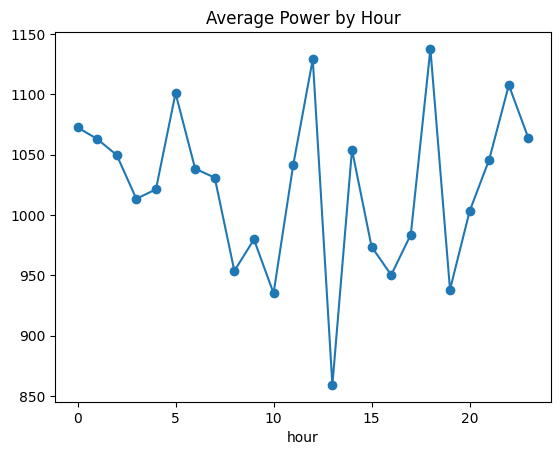

In [20]:
import matplotlib.pyplot as plt

df.groupby('hour')['total_power'].mean().plot(marker='o')
plt.title("Average Power by Hour")
plt.show()

In [ ]:
##maximum power by hour

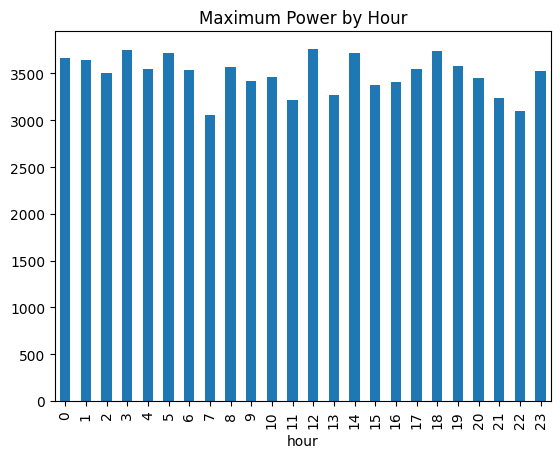

In [21]:
df.groupby('hour')['total_power'].max().plot(kind='bar')
plt.title("Maximum Power by Hour")
plt.show()

In [ ]:
##minimum power by hour

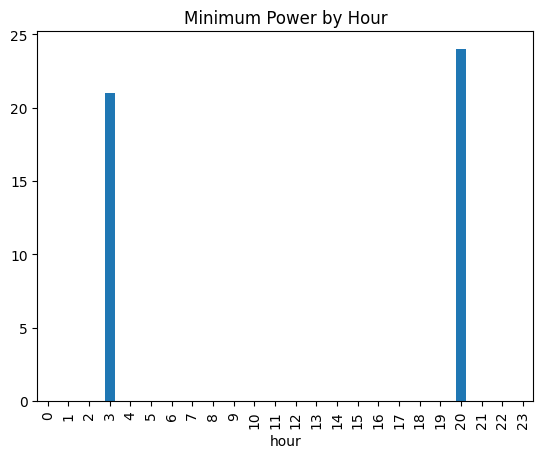

In [22]:
df.groupby('hour')['total_power'].min().plot(kind='bar')
plt.title("Minimum Power by Hour")
plt.show()

In [ ]:
##Device-wise Hourly Usage

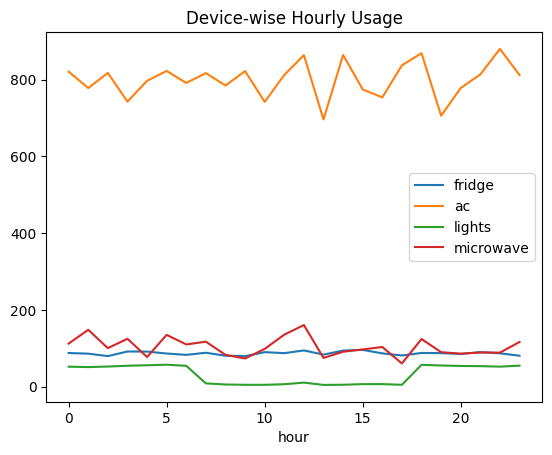

In [23]:
df.groupby('hour')[['fridge','ac','lights','microwave']].mean().plot()
plt.title("Device-wise Hourly Usage")
plt.show()

In [ ]:
##Peak Hour Detection

In [24]:
peak_hour = df.groupby('hour')['total_power'].mean().idxmax()
print("Peak usage hour:", peak_hour)

Peak usage hour: 18


In [ ]:
##weekly.ipynb

In [25]:
df['day_type'] = df.index.dayofweek.map(lambda x: 'Weekend' if x >= 5 else 'Weekday')
df.head()

,fridge,ac,lights,microwave,total_power,hour,trend,detrended,day_type
timestamp,,,,,,,,,
2023-01-01 00:00:00,0,1955,24,0,1979,0,NaN,NaN,Weekend
2023-01-01 01:00:00,186,0,81,0,267,1,NaN,NaN,Weekend
2023-01-01 02:00:00,111,1300,67,0,1478,2,NaN,NaN,Weekend
2023-01-01 03:00:00,0,0,93,0,93,3,NaN,NaN,Weekend
2023-01-01 04:00:00,0,0,26,0,26,4,NaN,NaN,Weekend


In [ ]:
##weeday vs weekend

In [26]:
daytype_table = df.groupby('day_type').agg({
    'total_power': ['mean','max','min'],
    'fridge': 'mean',
    'ac': 'mean',
    'lights': 'mean',
    'microwave': 'mean'
})

daytype_table

total_power               fridge          ac     lights   microwave
                 mean   max min       mean        mean       mean        mean
day_type                                                                     
Weekday   1007.794317  3762   0  87.313529  788.803035  32.291895   99.385857
Weekend   1060.474673  3746   0  85.638072  827.373366  31.798203  115.665033

In [ ]:
##Compare Total Power

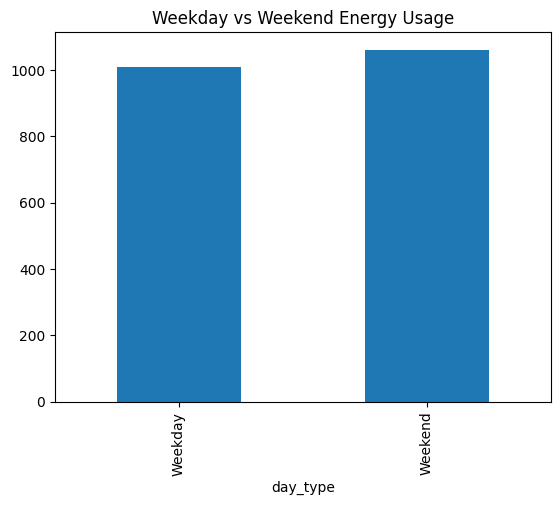

In [27]:
import matplotlib.pyplot as plt

df.groupby('day_type')['total_power'].mean().plot(kind='bar')
plt.title("Weekday vs Weekend Energy Usage")
plt.show()

In [ ]:
##Hourly Pattern for Weekday vs Weekend

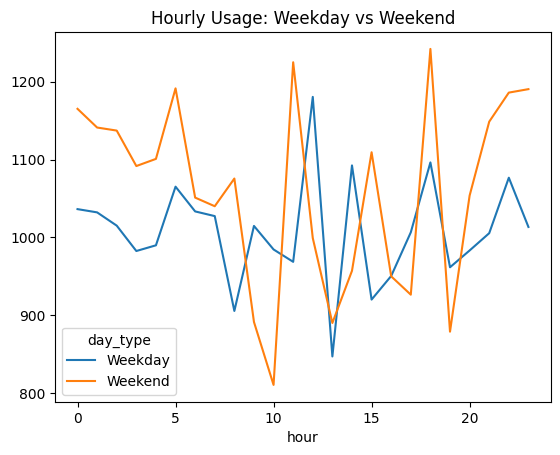

In [28]:
df['hour'] = df.index.hour

df.groupby(['hour','day_type'])['total_power'].mean().unstack().plot()
plt.title("Hourly Usage: Weekday vs Weekend")
plt.show()

In [ ]:
##Device-wise Comparison

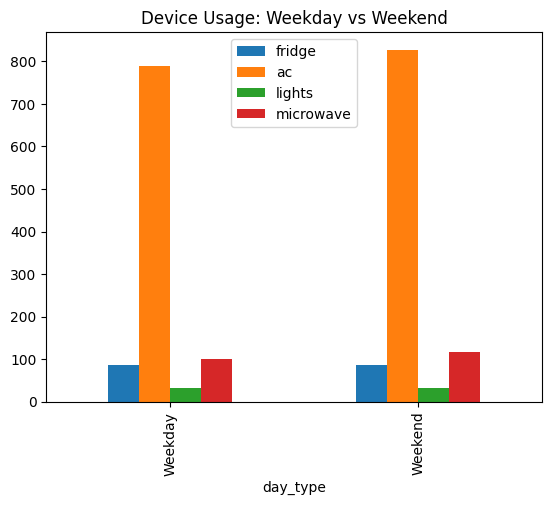

In [29]:
df.groupby('day_type')[['fridge','ac','lights','microwave']].mean().plot(kind='bar')
plt.title("Device Usage: Weekday vs Weekend")
plt.show()

In [ ]:
##Peak Time (Weekday vs Weekend) 

In [30]:
peak = df.groupby(['hour','day_type'])['total_power'].mean().reset_index()

weekday_peak = peak[peak['day_type']=='Weekday'].sort_values('total_power', ascending=False).iloc[0]
weekend_peak = peak[peak['day_type']=='Weekend'].sort_values('total_power', ascending=False).iloc[0]

print("Weekday Peak Hour:", weekday_peak['hour'])
print("Weekend Peak Hour:", weekend_peak['hour'])

Weekday Peak Hour: 12
Weekend Peak Hour: 18


In [ ]:
##Energy Difference (Insight Program)

In [31]:
weekday_avg = df[df['day_type']=='Weekday']['total_power'].mean()
weekend_avg = df[df['day_type']=='Weekend']['total_power'].mean()

print("Weekday Avg:", weekday_avg)
print("Weekend Avg:", weekend_avg)
print("Difference:", weekend_avg - weekday_avg)

Weekday Avg: 1007.7943170810462
Weekend Avg: 1060.4746732026144
Difference: 52.68035612156825


In [ ]:
##monthly.ipynb

In [32]:
df['month'] = df.index.month
df['month_name'] = df.index.month_name()
df.head()

,fridge,ac,lights,microwave,total_power,hour,trend,detrended,day_type,month,month_name
timestamp,,,,,,,,,,,
2023-01-01 00:00:00,0,1955,24,0,1979,0,NaN,NaN,Weekend,1,January
2023-01-01 01:00:00,186,0,81,0,267,1,NaN,NaN,Weekend,1,January
2023-01-01 02:00:00,111,1300,67,0,1478,2,NaN,NaN,Weekend,1,January
2023-01-01 03:00:00,0,0,93,0,93,3,NaN,NaN,Weekend,1,January
2023-01-01 04:00:00,0,0,26,0,26,4,NaN,NaN,Weekend,1,January


In [ ]:
##Monthly Summary Table 

In [33]:
monthly_table = df.groupby('month_name').agg({
    'total_power': ['mean','max','min'],
    'fridge': 'mean',
    'ac': 'mean',
    'lights': 'mean',
    'microwave': 'mean'
})

monthly_table

total_power               fridge           ac     lights  \
                   mean   max min       mean         mean       mean   
month_name                                                             
April       1648.825000  3723   0  85.298611  1418.615278  31.986111   
February     413.453869  3458   0  92.197917   173.843750  32.907738   
January      391.509409  3503   0  87.327957   178.043011  30.701613   
June        1646.467719  3744   0  87.460545  1423.837877  30.846485   
March        410.619624  3539   0  86.866935   186.518817  32.362903   
May         1626.065860  3762   0  82.389785  1416.334677  34.092742   

             microwave  
                  mean  
month_name              
April       112.925000  
February    114.504464  
January      95.436828  
June        104.322812  
March       104.870968  
May          93.248656

In [ ]:
##Total Power by Month

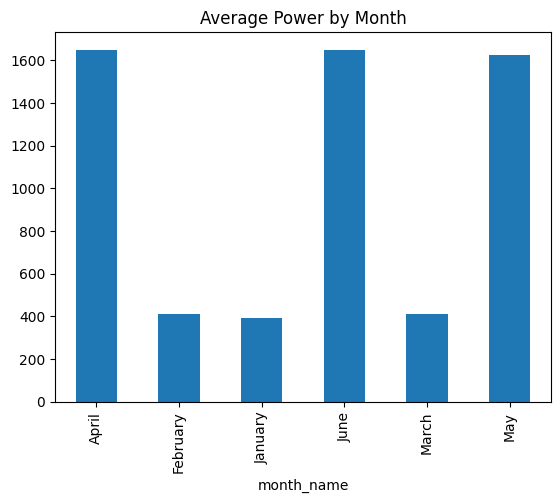

In [34]:
import matplotlib.pyplot as plt

df.groupby('month_name')['total_power'].mean().plot(kind='bar')
plt.title("Average Power by Month")
plt.show()

In [ ]:
##Compare Few Months

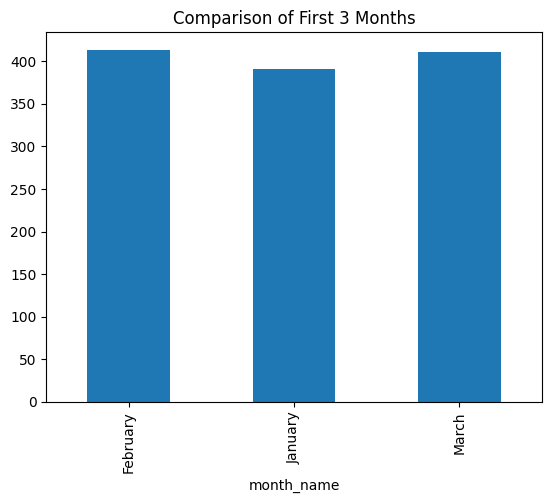

In [35]:
selected_months = ['January','February','March']

df[df['month_name'].isin(selected_months)] \
.groupby('month_name')['total_power'].mean() \
.plot(kind='bar')

plt.title("Comparison of First 3 Months")
plt.show()

In [ ]:
##Device Usage for Few Months 

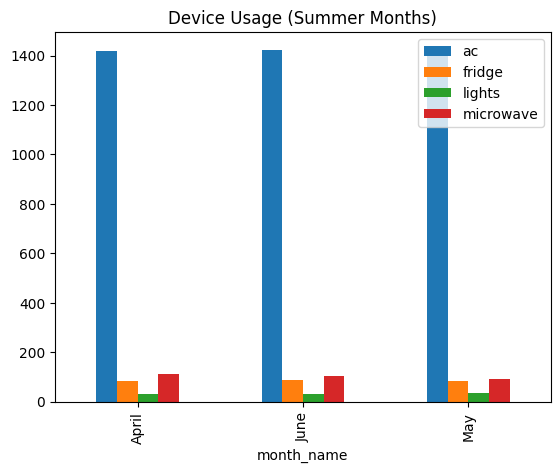

In [36]:
df[df['month_name'].isin(['April','May','June'])] \
.groupby('month_name')[['ac','fridge','lights','microwave']] \
.mean().plot(kind='bar')

plt.title("Device Usage (Summer Months)")
plt.show()

In [ ]:
##Monthly Peak Detection

In [37]:
peak_month = df.groupby('month_name')['total_power'].mean().idxmax()
print("Peak usage month:", peak_month)

Peak usage month: April


In [ ]:
##Monthly Trend Line 

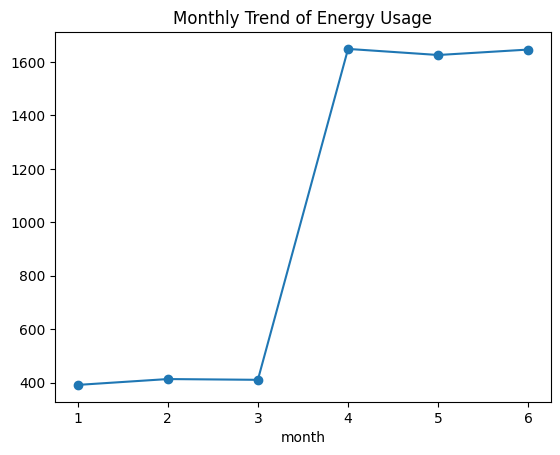

In [38]:
df.groupby('month')['total_power'].mean().plot(marker='o')
plt.title("Monthly Trend of Energy Usage")
plt.show()

In [ ]:
##Winter vs Summer comparison

In [39]:
winter = ['January','February','March']
summer = ['April','May','June']

print("Winter Avg:", df[df['month_name'].isin(winter)]['total_power'].mean())
print("Summer Avg:", df[df['month_name'].isin(summer)]['total_power'].mean())

Winter Avg: 404.91898148148147
Summer Avg: 1640.2290606200834


In [ ]:
## AC usage increase

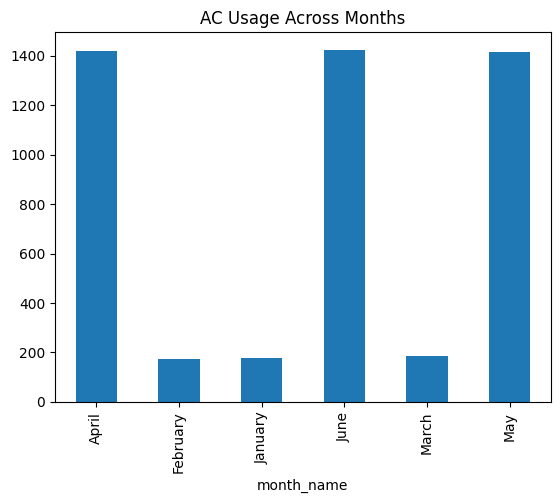

In [40]:
df.groupby('month_name')['ac'].mean().plot(kind='bar')
plt.title("AC Usage Across Months")
plt.show()

In [ ]:
##polynomial.ipynb

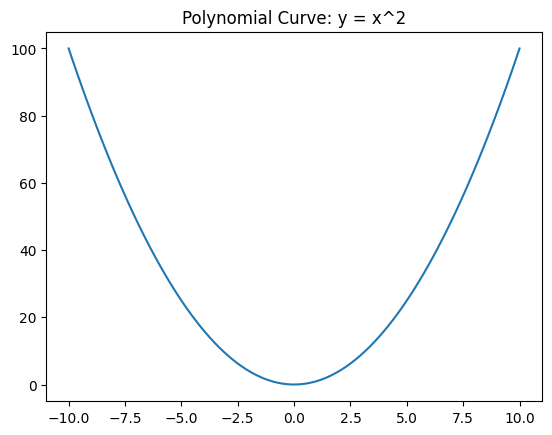

In [41]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
y = x**2

plt.plot(x, y)
plt.title("Polynomial Curve: y = x^2")
plt.show()

In [ ]:
##multiple polynomial curves

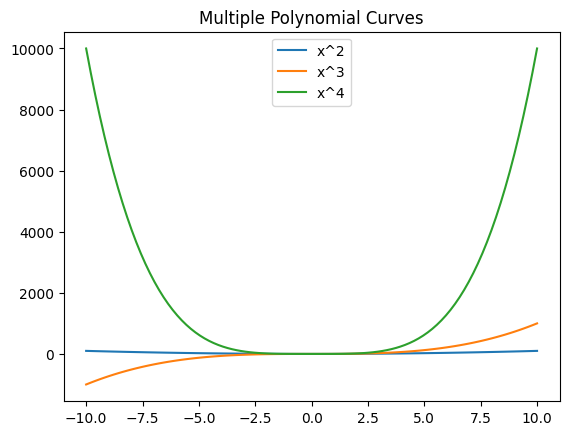

In [42]:
x = np.linspace(-10, 10, 100)

plt.plot(x, x**2, label="x^2")
plt.plot(x, x**3, label="x^3")
plt.plot(x, x**4, label="x^4")

plt.legend()
plt.title("Multiple Polynomial Curves")
plt.show()

In [ ]:
##polynomial regression 

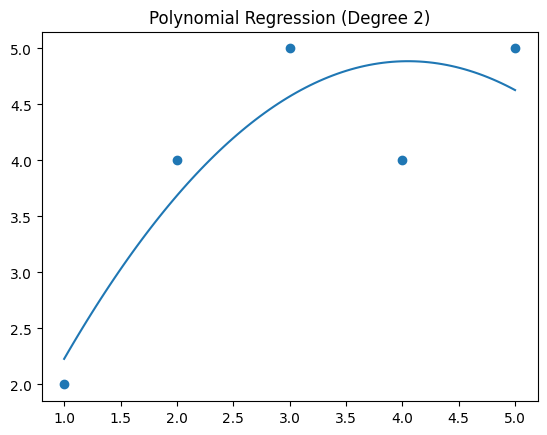

In [43]:
# sample data
x = np.array([1,2,3,4,5])
y = np.array([2,4,5,4,5])

# fit polynomial (degree 2)
coeff = np.polyfit(x, y, 2)
poly = np.poly1d(coeff)

# plot
x_new = np.linspace(1,5,100)
plt.scatter(x, y)
plt.plot(x_new, poly(x_new))
plt.title("Polynomial Regression (Degree 2)")
plt.show()

In [ ]:
##compare linear vs polynomial regression

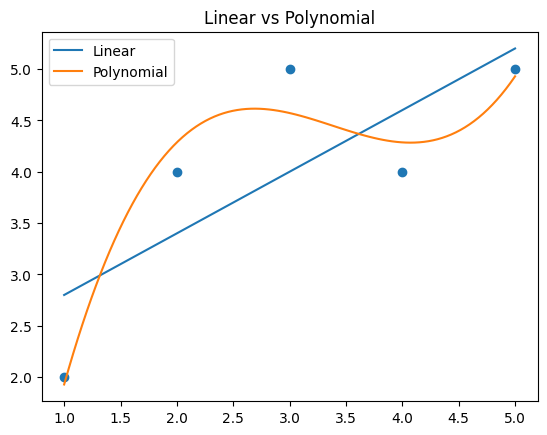

In [44]:
# linear fit
linear = np.polyfit(x, y, 1)
linear_fn = np.poly1d(linear)

# polynomial fit
poly = np.polyfit(x, y, 3)
poly_fn = np.poly1d(poly)

plt.scatter(x, y)
plt.plot(x_new, linear_fn(x_new), label="Linear")
plt.plot(x_new, poly_fn(x_new), label="Polynomial")

plt.legend()
plt.title("Linear vs Polynomial")
plt.show()

In [ ]:
prediction.ipynb

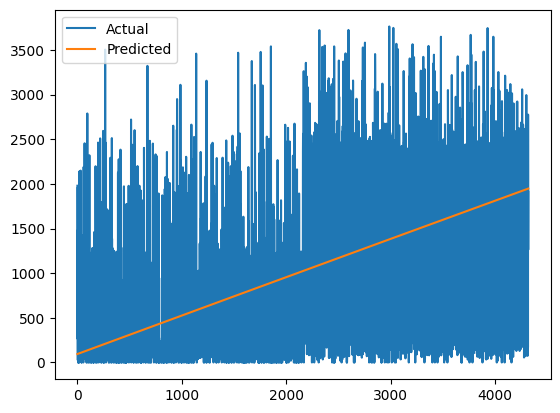

In [45]:
# Predict energy trend using polynomial
x = np.arange(len(df))
y = df['total_power']

coeff = np.polyfit(x, y, 2)
poly = np.poly1d(coeff)

plt.plot(x, y, label="Actual")
plt.plot(x, poly(x), label="Predicted")

plt.legend()
plt.show()